<a href="https://colab.research.google.com/github/Smothyze/naive-bayes-model/blob/main/Analisis_Model_Deteksi_Berita.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Bagian 1: Instalasi Library & Persiapan Awal**

>Sel ini berfungsi menyiapkan lingkungan kerja dan library yang diperlukan untuk pemrosesan teks bahasa Indonesia.

In [ ]:
# 1. INSTALL LIBRARY
!pip install sastrawi wordcloud

# 2. IMPORT LIBRARY UTAMA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from google.colab import drive
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 3. MOUNT GOOGLE DRIVE
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.3 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Bagian 2: Fungsi Prepocessing (Standar NLP)**

>Fungsi ini adalah "jantung" dari pembersihan data teks.

In [ ]:
def preprocessing_lengkap(teks):
    # a. Case Folding (Huruf kecil)
    teks = str(teks).lower()

    # b. Tokenizing (Menghapus karakter non-alfabet & split)
    import re
    teks = re.sub(r'[^a-zA-Z\s]', '', teks)

    # c. Stopword Removal (Sastrawi)
    stop_factory = StopWordRemoverFactory()
    stopword = stop_factory.create_stop_word_remover()
    teks = stopword.remove(teks)

    # d. Stemming (Sastrawi)
    stem_factory = StemmerFactory()
    stemmer = stem_factory.create_stemmer()
    teks = stemmer.stem(teks)

    return teks

**Bagian 3: Memuat Dataset & Menyiapkan Skenario**

>Sel ini memproses dataset besar dari Drive dan menyiapkan dua skenario: Unbalanced dan Balanced.

In [ ]:
# Load Dataset
path = '/content/drive/MyDrive/dataset_unbalanced_full.csv'
df = pd.read_csv(path).dropna()
df['text_cleaned'] = df['text_cleaned'].fillna(' ')

# --- SKENARIO 1: UNBALANCED (Asli) ---
X_un = df['text_cleaned']
y_un = df['label']

# --- SKENARIO 2: BALANCED (1:1) ---
df_hoax = df[df['label'] == 1]
df_valid = df[df['label'] == 0].sample(n=len(df_hoax), random_state=42)
df_bal = pd.concat([df_hoax, df_valid]).sample(frac=1, random_state=42)

X_ba = df_bal['text_cleaned']
y_ba = df_bal['label']

print(f"Data Unbalanced: {len(df)} baris")
print(f"Data Balanced: {len(df_bal)} baris")

Data Unbalanced: 27422 baris
Data Balanced: 12954 baris


**Bagian 4: Pelatihan Model, Evaluasi Metrik & Confussion Matrix**

>Ini merupakan inti dari eksperimen perbandingan.


Training Multinomial (Unbalanced)...


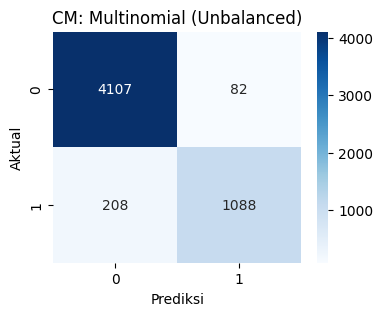


Training Bernoulli (Unbalanced)...


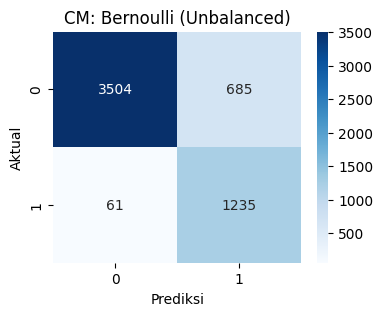


Training Gaussian (Unbalanced)...


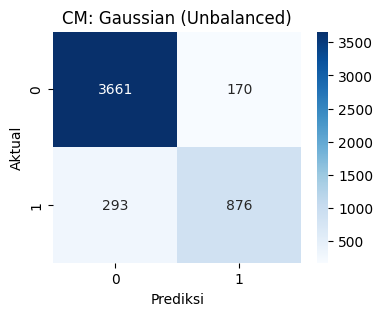


Training Multinomial (Balanced)...


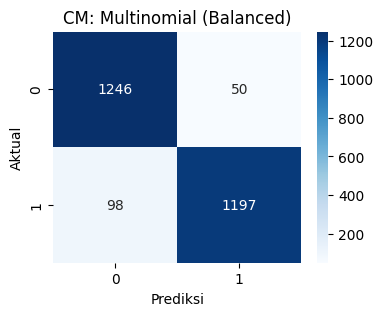


Training Bernoulli (Balanced)...


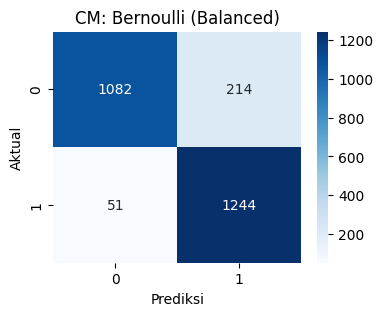


Training Gaussian (Balanced)...


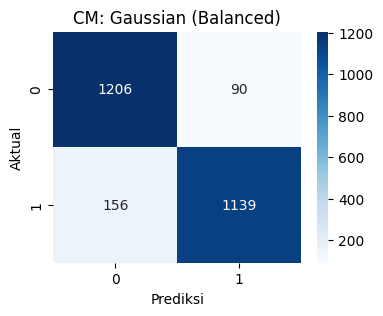


--- RINGKASAN EVALUASI AKHIR ---


,Model,Accuracy,Precision_Hoax,Recall_Hoax,F1_Hoax
0,Multinomial (Unbalanced),0.947129,0.929915,0.839506,0.882401
1,Bernoulli (Unbalanced),0.863993,0.643229,0.952932,0.768035
2,Gaussian (Unbalanced),0.907400,0.837476,0.749358,0.790971
3,Multinomial (Balanced),0.942879,0.959904,0.924324,0.941778
4,Bernoulli (Balanced),0.897723,0.853224,0.960618,0.903741
5,Gaussian (Balanced),0.905056,0.926770,0.879537,0.902536


In [ ]:
# Inisialisasi Vectorizer
tfidf = TfidfVectorizer(max_features=5000)

def train_and_evaluate(X, y, scenario_name):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Transformasi TF-IDF
    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf = tfidf.transform(X_test)

    models = [
        ("Multinomial", MultinomialNB()),
        ("Bernoulli", BernoulliNB()),
        ("Gaussian", GaussianNB())
    ]

    results = []

    for name, m in models:
        print(f"\nTraining {name} ({scenario_name})...")

        if name == "Gaussian":
            # BATASI DATA HANYA 5000 SAMPLE
            max_samples = 5000

            if X_train_tfidf.shape[0] > max_samples:
                X_train_g = X_train_tfidf[:max_samples].toarray()
                y_train_g = y_train[:max_samples]
            else:
                X_train_g = X_train_tfidf.toarray()
                y_train_g = y_train

            if X_test_tfidf.shape[0] > max_samples:
                X_test_g = X_test_tfidf[:max_samples].toarray()
                y_test_g = y_test[:max_samples]
            else:
                X_test_g = X_test_tfidf.toarray()
                y_test_g = y_test

            m.fit(X_train_g, y_train_g)
            y_pred = m.predict(X_test_g)

            # Gunakan y_test_g untuk evaluasi Gaussian
            y_eval = y_test_g

        else:
            m.fit(X_train_tfidf, y_train)
            y_pred = m.predict(X_test_tfidf)
            y_eval = y_test

        # Simpan Model
        joblib.dump(m, f"model_{name.lower()}_{scenario_name.lower()}.pkl")
        joblib.dump(tfidf, f"tfidf_{scenario_name.lower()}.pkl")

        # Evaluasi
        acc = accuracy_score(y_eval, y_pred)
        pre = precision_score(y_eval, y_pred)
        rec = recall_score(y_eval, y_pred)
        f1  = f1_score(y_eval, y_pred)

        results.append([f"{name} ({scenario_name})", acc, pre, rec, f1])

        # Confusion Matrix
        cm = confusion_matrix(y_eval, y_pred)
        plt.figure(figsize=(4,3))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f"CM: {name} ({scenario_name})")
        plt.xlabel("Prediksi"); plt.ylabel("Aktual")
        plt.show()

    return results

# Jalankan Eksperimen
res_un = train_and_evaluate(X_un, y_un, "Unbalanced")
res_ba = train_and_evaluate(X_ba, y_ba, "Balanced")

# Tampilkan Tabel Final
df_res = pd.DataFrame(
    res_un + res_ba,
    columns=['Model', 'Accuracy', 'Precision_Hoax', 'Recall_Hoax', 'F1_Hoax']
)

print("\n--- RINGKASAN EVALUASI AKHIR ---")
display(df_res)

**Bagian 5: Visualisasi Word Cloud**

>Memberikan bukti visual perbedaan diksi antara hoaks dan valid.

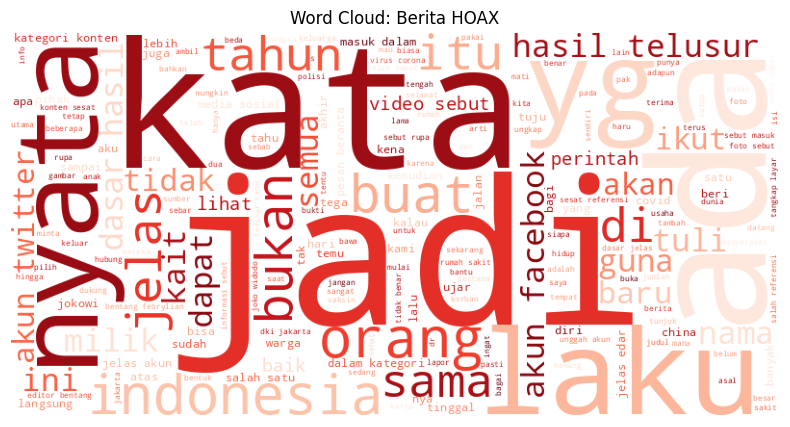

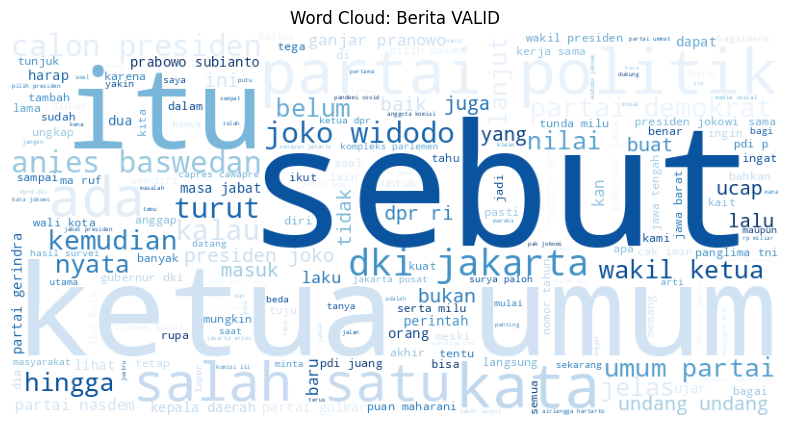

In [ ]:
def plot_cloud(label, title, color):
    text = " ".join(df[df['label'] == label]['text_cleaned'].astype(str))
    wc = WordCloud(width=800, height=400, background_color='white', colormap=color).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc)
    plt.title(f"Word Cloud: Berita {title}")
    plt.axis('off'); plt.show()

plot_cloud(1, "HOAX", "Reds")
plot_cloud(0, "VALID", "Blues")

**Bagian 6: Pengetesan Berita Manual**

>Sel ini yang digunakan untuk demo input berita manual.

In [ ]:
def manual_test_komparatif():
    print("--- SISTEM DETEKSI BERITA HOAKS (KOMPARASI MODEL) ---")
    kalimat_input = input("Masukkan teks berita yang ingin diuji: ")
    skenario_pilihan = input("Pilih skenario model (balanced/unbalanced): ").lower()

    try:
        # 1. Load TF-IDF dan ketiga Model sesuai skenario
        v = joblib.load(f"tfidf_{skenario_pilihan}.pkl")
        m_mnb = joblib.load(f"model_multinomial_{skenario_pilihan}.pkl")
        m_bnb = joblib.load(f"model_bernoulli_{skenario_pilihan}.pkl")
        m_gnb = joblib.load(f"model_gaussian_{skenario_pilihan}.pkl")

        # 2. Preprocessing & Transformasi Fitur
        teks_bersih = preprocessing_lengkap(kalimat_input)
        vektor_tfidf = v.transform([teks_bersih])

        # 3. Prediksi Multinomial NB
        pred_mnb = m_mnb.predict(vektor_tfidf)[0]
        prob_mnb = m_mnb.predict_proba(vektor_tfidf)[0][pred_mnb]

        # 4. Prediksi Bernoulli NB
        pred_bnb = m_bnb.predict(vektor_tfidf)[0]
        prob_bnb = m_bnb.predict_proba(vektor_tfidf)[0][pred_bnb]

        # 5. Prediksi Gaussian NB (Wajib .toarray() karena format dense)
        vektor_dense = vektor_tfidf.toarray()
        pred_gnb = m_gnb.predict(vektor_dense)[0]
        prob_gnb = m_gnb.predict_proba(vektor_dense)[0][pred_gnb]

        # 6. Menampilkan Hasil dalam Tabel
        data_hasil = [
            ["Multinomial NB", "HOAKS" if pred_mnb == 1 else "VALID", f"{prob_mnb*100:.2f}%"],
            ["Bernoulli NB", "HOAKS" if pred_bnb == 1 else "VALID", f"{prob_bnb*100:.2f}%"],
            ["Gaussian NB", "HOAKS" if pred_gnb == 1 else "VALID", f"{prob_gnb*100:.2f}%"]
        ]

        df_hasil = pd.DataFrame(data_hasil, columns=["Algoritma", "Hasil Prediksi", "Tingkat Keyakinan"])

        print(f"\n--- HASIL PENGUJIAN MANUAL (SKENARIO: {skenario_pilihan.upper()}) ---")
        print(f"Teks Input: \"{kalimat_input[:100]}...\"")
        print("-" * 65)
        display(df_hasil)
        print("-" * 65)

    except FileNotFoundError:
        print(f"Error: File model atau TF-IDF untuk skenario '{skenario_pilihan}' tidak ditemukan. Pastikan Anda sudah menjalankan Sel 4.")
    except Exception as e:
        print(f"Terjadi kesalahan: {e}")

# Jalankan Demo
manual_test_komparatif()

--- SISTEM DETEKSI BERITA HOAKS (KOMPARASI MODEL) ---
Masukkan teks berita yang ingin diuji: Kepala BGN Dadan Hindayana mengatakan sebanyak 1.780 SPPG ditangguhkan atau dihentikan sementara (suspend) dalam rangka pengawasan dan perbaikan Program MBG.  "SPPG-SPPG yang tidak memiliki Instalasi Pengolahan Air Limbah (IPAL) atau belum daftar Sertifikat Laik Higiene dan Sanitasi (SLHS), kita hentikan dulu sementara. Ketika sudah daftar SLHS tapi satu bulan belum keluar sertifikatnya, kita hentikan sementara," ujar Dadan, Kamis.  Saat ini terdapat sekitar 1.780 SPPG yang dihentikan sementara dari total 26.800 unit. Namun, angka tersebut bersifat dinamis dan dapat berubah seiring proses perbaikan.
Pilih skenario model (balanced/unbalanced): balanced

--- HASIL PENGUJIAN MANUAL (SKENARIO: BALANCED) ---
Teks Input: "Kepala BGN Dadan Hindayana mengatakan sebanyak 1.780 SPPG ditangguhkan atau dihentikan sementara (su..."
-----------------------------------------------------------------


,Algoritma,Hasil Prediksi,Tingkat Keyakinan
0,Multinomial NB,VALID,59.52%
1,Bernoulli NB,HOAKS,100.00%
2,Gaussian NB,VALID,100.00%


-----------------------------------------------------------------
